# 　Batch Normalization 的算法

In [1]:

import sys, os
sys.path.append(os.pardir)
import numpy as np
from typing import Dict, List
import matplotlib.pyplot as plt

from libs.network import NeuralNet
from libs.trainer import Trainer
from libs.util import smooth_curve

# 设置字体为华文细黑
plt.rcParams['font.sans-serif'] = ['STHeiti']  # macOS 上的华文细黑
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

In [2]:
# 加载数据集
from dataset.mnist import load_mnist

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, flatten=True, one_hot_label=True)

print(x_train.shape)
print(t_train.shape)
print(x_test.shape)
print(t_test.shape)


save_file: /Users/simeon/WorkSpace/Projects/Practice/DeepLearnStudy/example/../dataset/data/mnist.pkl
(60000, 784)
(60000, 10)
(10000, 784)
(10000, 10)


In [3]:
def start_train(optimizer: str='sgd', hidden_size_list: List[int]=[100, 100], epochs: int=5, mini_batch_size: int=100, activation: str="relu", weight_scale: str|float="he", use_batchnorm: bool=False) -> List[float]:
    trainer = Trainer(
        network=NeuralNet(input_size=x_train.shape[1], hidden_size_list=hidden_size_list, output_size=t_train.shape[1], activation=activation, weight_scale=weight_scale, use_batchnorm=use_batchnorm),
        x_train=x_train,
        t_train=t_train,
        x_test=x_test,
        t_test=t_test,
        optimizer=optimizer,
        # optimizer_param=optimizer_param,
        epochs=epochs,
        mini_batch_size=mini_batch_size,
        verbose=True
    )
    trainer.train()
    return trainer.train_loss_list, trainer.train_acc_list, trainer.test_acc_list

In [4]:
trainers = [
    {
        'optimizer': 'sgd',
        'activation': 'relu',
        'weight_scale': 0.0,
        'losses': []
    },
    {
        'optimizer': 'sgd',
        'activation': 'relu',
        'weight_scale': 0.01,
        'losses': []
    },
    {
        'optimizer': 'sgd',
        'activation': 'relu',
        'weight_scale': 0.05,
        'losses': []
    },
    {
        'optimizer': 'sgd',
        'activation': 'relu',
        'weight_scale': 0.1,
        'losses': []
    },
    {
        'optimizer': 'sgd',
        'activation': 'relu',
        'weight_scale': 0.2,
        'losses': []
    },
    {
        'optimizer': 'sgd',
        'activation': 'relu',
        'weight_scale': 0.5,
        'losses': []
    },
    {
        'optimizer': 'sgd',
        'activation': 'relu',
        'weight_scale': 1.0,
        'losses': []
    },
    {
        'optimizer': 'adam',
        'activation': 'relu',
        'weight_scale': 'he',
        'losses': []
    },
    {
        'optimizer': 'adam',
        'activation': 'sigmoid',
        'weight_scale': 'xavier',
        'losses': []
    },
    {
        'optimizer': "sgd",
        'activation': 'sigmoid',
        'weight_scale': 0.0,
        'losses': []
    },
    {
        'optimizer': "sgd",
        'activation': 'sigmoid',
        'weight_scale': 0.01,
        'losses': []
    },
    {
        'optimizer': "sgd",
        'activation': 'sigmoid',
        'weight_scale': 0.5,
        'losses': []
    }
]

for trainer in trainers:
    optimizer = trainer['optimizer']
    activation = trainer['activation']
    weight_scale = trainer['weight_scale']
    
    # 训练
    train_loss, _, _ = start_train(optimizer, activation=activation, weight_scale=weight_scale)
    train_loss_use_batchnorm, _, _ = start_train(optimizer, activation=activation, weight_scale=weight_scale, use_batchnorm=True)
    trainer['losses'] = [train_loss, train_loss_use_batchnorm]
    


网络结构:
	【全连接层】: Affine1, W1(784:100), b1(100)
	【激活层】: Relu1
	【全连接层】: Affine2, W2(100:100), b2(100)
	【激活层】: Relu2
	【全连接层】: Affine3, W3(100:10), b3(10)
	【Softmax + Loss】
开始训练...
epoch:1, loss:230.2456157124511, train acc:0.10441666666666667, test acc:0.1028
epoch:2, loss:230.15974576106652, train acc:0.11236666666666667, test acc:0.1135
epoch:3, loss:230.08445431283434, train acc:0.11236666666666667, test acc:0.1135
epoch:4, loss:230.10214140170126, train acc:0.11236666666666667, test acc:0.1135
epoch:5, loss:229.94017170561648, train acc:0.11236666666666667, test acc:0.1135
=============== Final Test Accuracy ===============
test acc:0.1135
网络结构:
	【全连接层】: Affine1, W1(784:100), b1(100)
	【批归一化层】: BatchNorm1
	【激活层】: Relu1
	【全连接层】: Affine2, W2(100:100), b2(100)
	【批归一化层】: BatchNorm2
	【激活层】: Relu2
	【全连接层】: Affine3, W3(100:10), b3(10)
	【Softmax + Loss】
开始训练...
epoch:1, loss:230.24761471030357, train acc:0.09915, test acc:0.1009
epoch:2, loss:229.85054713473284, train acc:0.11236666666666667, te

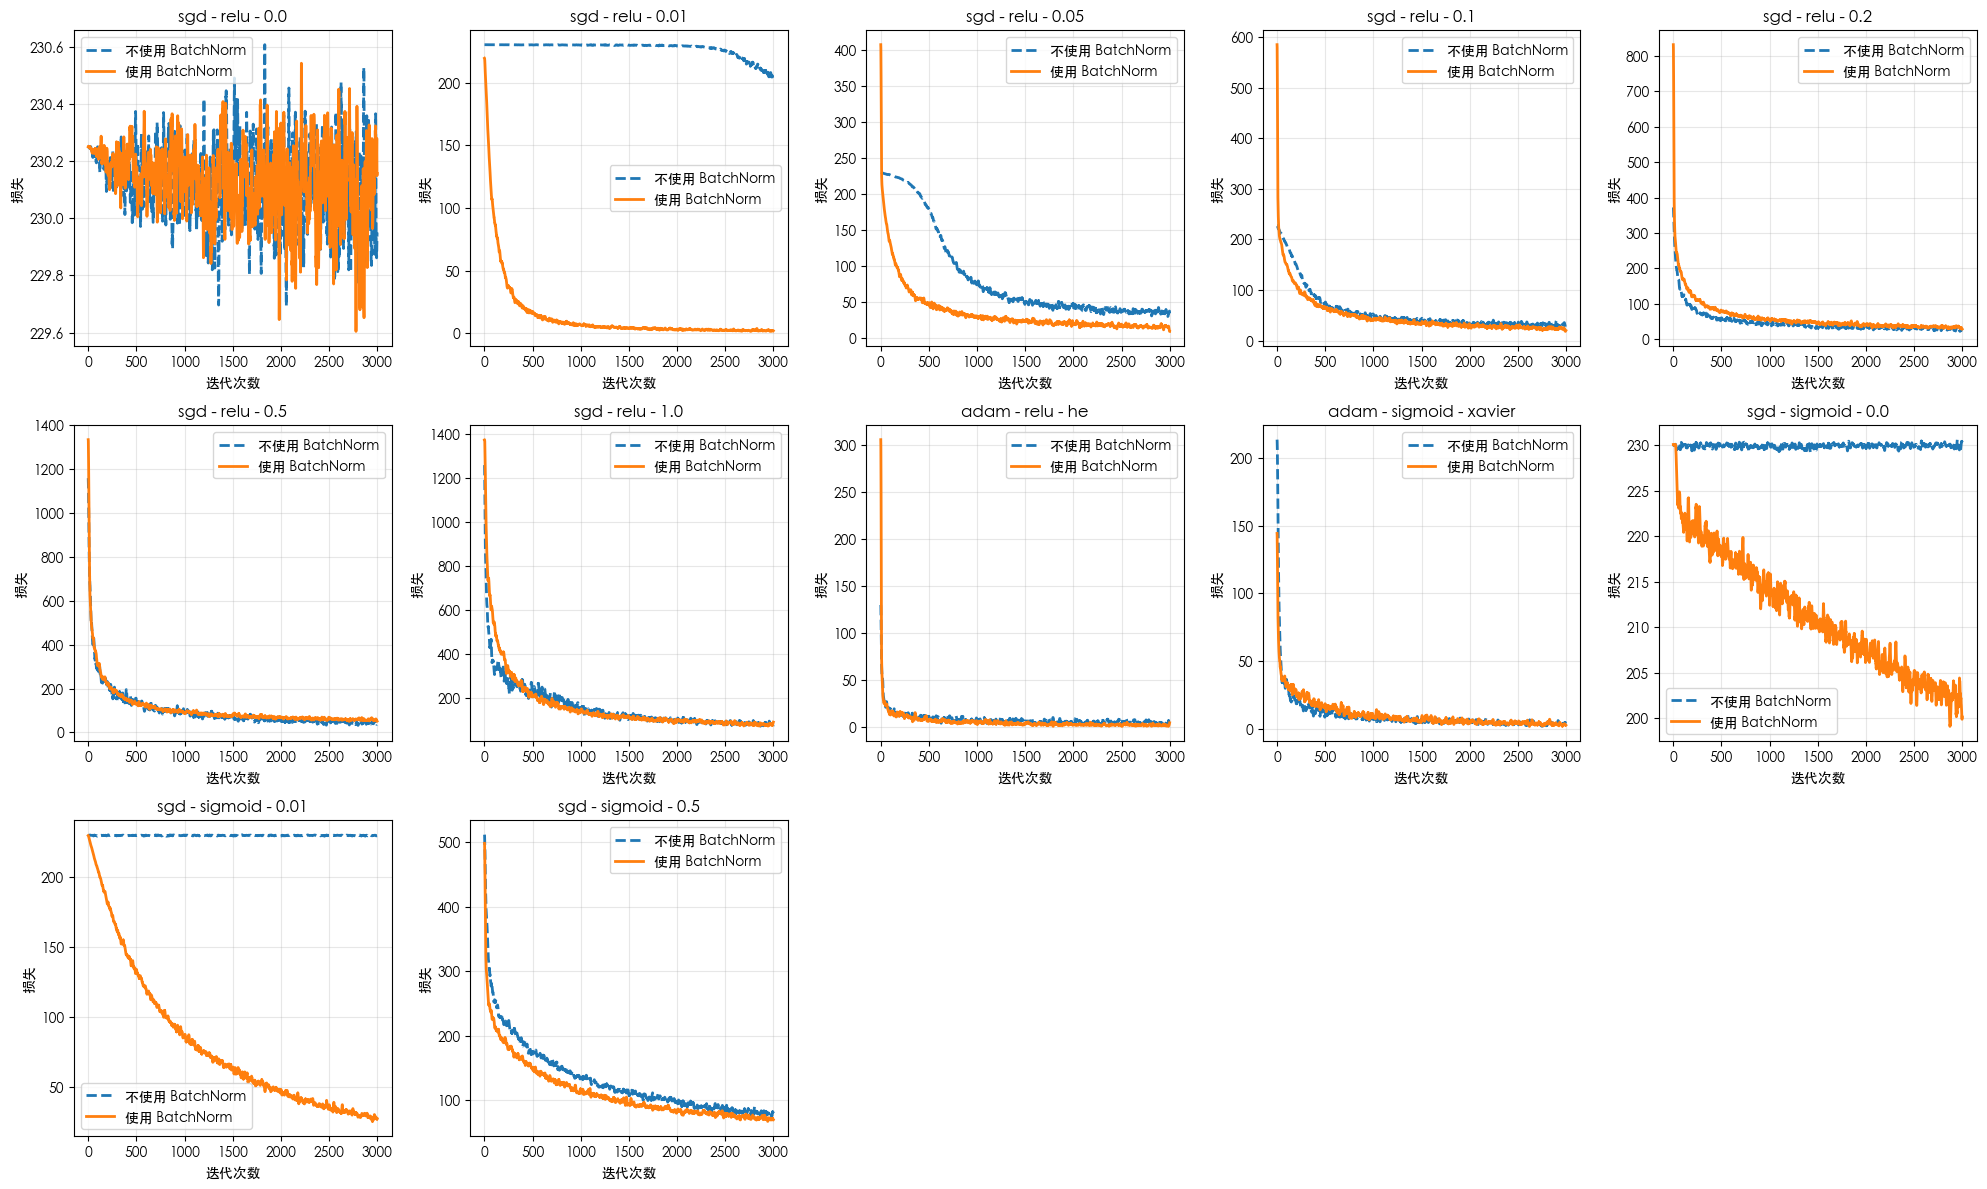

In [5]:
# 绘制损失曲线
def plot_loss_curves(train_losses: List[Dict[str, any]]):
    num_plots = len(train_losses)
    # 计算合适的行列数
    cols = 5
    rows = (num_plots + cols - 1) // cols  # 向上取整
    
    fig, axes = plt.subplots(rows, cols, figsize=(20, 4*rows))
    
    # 如果只有一行，确保axes是二维数组
    if rows == 1:
        axes = axes.reshape(1, -1)
    # 如果只有一列，确保axes是二维数组
    elif cols == 1:
        axes = axes.reshape(-1, 1)
    
    axes = axes.flatten()
    
    for i, loss_info in enumerate(train_losses):
        optimizer = loss_info['optimizer']
        activation = loss_info['activation']
        weight_scale = loss_info['weight_scale']
        losses = loss_info['losses']
        
        ax = axes[i]
        # 实线为没有使用BatchNorm，虚线为使用BatchNorm
        ax.plot(smooth_curve(losses[0]), linestyle='--', label='不使用 BatchNorm', linewidth=2)
        ax.plot(smooth_curve(losses[1]), label='使用 BatchNorm', linewidth=2)
        
        ax.set_title(f'{optimizer} - {activation} - {weight_scale}')
        ax.set_xlabel('迭代次数')
        ax.set_ylabel('损失')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # 隐藏多余的子图
    for i in range(num_plots, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()

plot_loss_curves(trainers)